In [99]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)

In [119]:
train_df = pd.read_csv("malaria_train.csv")
test_df = pd.read_csv("malaria_test.csv")
val_df = pd.read_csv("malaria_val.csv")

# T_train,T_val, = train_test_split(
#     train_df,test_size=0.2, random_state=42,
# )


X_train = train_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_train = train_df['Malaria_Positive'].values.astype(np.float32)

X_val = val_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_val = val_df['Malaria_Positive'].values.astype(np.float32)


X_test = test_df.drop(columns=['Malaria_Positive']).values.astype(np.float32)
y_test = test_df['Malaria_Positive'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f" val: {X_val.shape}")
print(f" Test: {X_test.shape}")


print(f" number of features: {X_train.shape[1]}")

Train: (560, 15)
 val: (120, 15)
 Test: (120, 15)
 number of features: 15


In [120]:
with open("malaria_train.json") as f:
    data = json.load(f)
df = pd.DataFrame(data)
target = "Malaria_Positive"
feature = [
    col for col in df.columns
    if col != target
]
X = df[feature].values.astype(np.float32)
y = df[target].values.astype(np.float32)

print("Loaded malaria dataset")
print(f"Number of features: {len(feature)}")
print(f"Features: {feature}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Loaded malaria dataset
Number of features: 15
Features: ['Age', 'Fever_Temp', 'Chills', 'Headache_Severity', 'Vomiting', 'Diarrhea', 'Muscle_Pain', 'Fatigue_Level', 'Sweating', 'Nausea', 'High_Fever', 'Fever_x_Chills', 'Severe_Headache', 'Symptom_Count', 'Vulnerable_Age']
X shape: (560, 15)
y shape: (560,)


In [121]:
def build_ann(No_features):
    inputs = keras.Input(shape=(No_features,), name="features")

    X= keras.layers.Dense(128, kernel_regularizer = keras.regularizers.l2(1e-4))(inputs)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.3)(X)


    X= keras.layers.Dense(64, kernel_regularizer = keras.regularizers.l2(1e-4))(X)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.3)(X)

    X= keras.layers.Dense(32)(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.2)(X)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(X)
    return keras.Model(inputs, outputs, name="maleriaANN")

In [122]:
model = build_ann(X_train.shape[1])
model.summary()

Model: "maleriaANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 15)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_19 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_20 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_21 (Activation)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [123]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss = 'binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [124]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=25,
        
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_malaria_model.keras", monitor="val_loss",
        save_best_only = True, mode='max', verbose=0
    ),
]
history = model.fit(
    X_train, y_train,
    epochs = 300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks = callbacks, verbose=1,
)
print(f"\nEpochs run: {len(history.history['loss'])}")
print(f"best val AUC: {max(history.history['val_loss']):.4f}")

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.7125 - auc: 0.6992 - loss: 0.6353 - precision: 0.7903 - recall: 0.4206 - val_accuracy: 0.9000 - val_auc: 0.9721 - val_loss: 0.5702 - val_precision: 0.9318 - val_recall: 0.8200 - learning_rate: 5.0000e-04
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8571 - auc: 0.9297 - loss: 0.4152 - precision: 0.8696 - recall: 0.7725 - val_accuracy: 0.9583 - val_auc: 0.9960 - val_loss: 0.4310 - val_precision: 0.9091 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9375 - auc: 0.9824 - loss: 0.2890 - precision: 0.9342 - recall: 0.9142 - val_accuracy: 0.9583 - val_auc: 0.9977 - val_loss: 0.3260 - val_precision: 0.9091 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9554 - auc: 0.9924 - loss: 0.2177 - precision: 0.9483 - recall: 0.9442 - val_accuracy: 0.9667 - val_auc: 0.9981 - val_loss

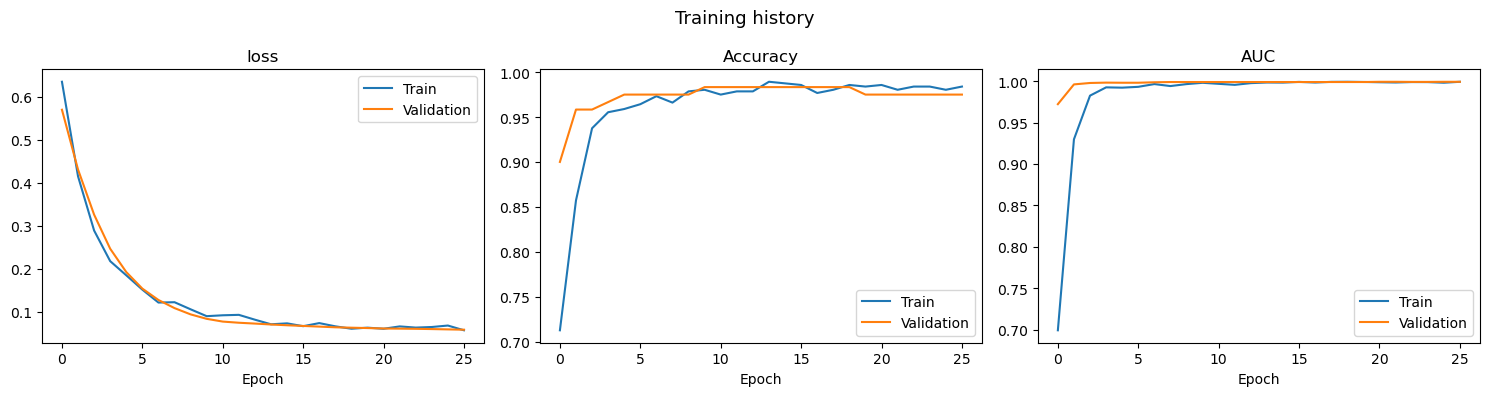

In [133]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history["loss"], label='Train')
axes[0].plot(history.history["val_loss"], label='Validation')
axes[0].set_title("loss")
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history["accuracy"], label='Train')
axes[1].plot(history.history["val_accuracy"], label='Validation')
axes[1].set_title("Accuracy")
axes[1].set_xlabel('Epoch')
axes[1].legend()

# axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color="steelblue")
axes[2].plot(history.history['auc'],  label='Train')
axes[2].plot(history.history['val_auc'],  label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('Training history', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [125]:

model.load_weights('best_malaria_model.keras')
test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.5685
compile_metrics: 0.9417


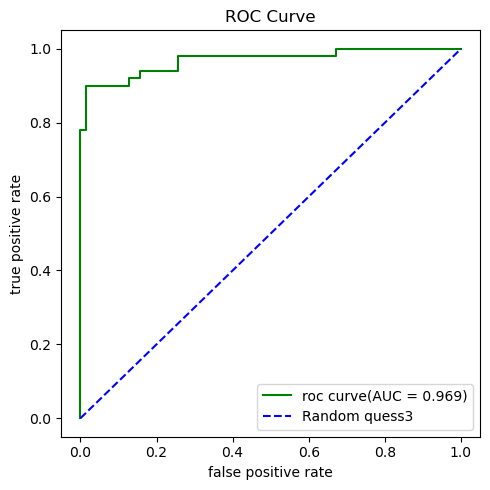

ROC-AUC: 0.9689


In [126]:
y_prob = model.predict(X_test, verbose = 0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, color='green', label=f'roc curve(AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1], color='blue', linestyle='--', label="Random quess3")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

              precision    recall  f1-score   support

  No malaria       0.92      0.99      0.95        70
     malaria       0.98      0.88      0.93        50

    accuracy                           0.94       120
   macro avg       0.95      0.93      0.94       120
weighted avg       0.94      0.94      0.94       120



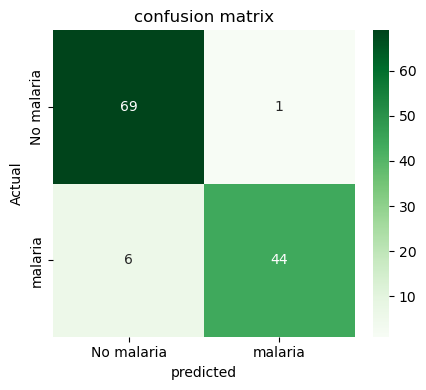

In [129]:
y_pred = (y_prob >= 0.5).astype(int)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

print(classification_report(y_test, y_pred, target_names=['No malaria', 'malaria']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
           xticklabels=['No malaria', 'malaria'],
           yticklabels=['No malaria', 'malaria'])
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.title("confusion matrix")
plt.tight_layout()
plt.savefig('confusion_matrix_formalaria.png', dpi=150, bbox_inches = 'tight')
plt.show()

In [130]:
model.save('malaria_ann.keras')
with open('malaria_inference_kit.pkl', 'wb') as f:
    pickle.dump({
        'feature': feature,
    }, f)
print('saved malaria_ann.keras')
print('saved malaria_inference_kit.pkl')

saved malaria_ann.keras
saved malaria_inference_kit.pkl


In [111]:
# def predict_malaria(patient, model, feature, threshold=0.5):
#     patient = patient.copy()
#     row = np.array(
#         [patient[col] for col in feature],
#         dtype=np.float32
#     ).reshape(1, -1)

#     probability = float(
#         model.predict(row, verbose=0)[0][0]
#     )

#     prediction = int(probability >= threshold)

#     result = {
#         "probability": probability,
#         "percentage": probability * 100,
#         "prediction": prediction,
#         "result": (
#             "Malaria"
#             if prediction == 1
#             else "No malaria"
#         )
#     }

#     return result

In [137]:
# result = predict_malaria(
#     patient,
#     model,
#     feature
# )

# print(f"Probability: {result['percentage']:.2f}%")
# print(f"Result: {result['result']}")

In [138]:
# patient_1 = {
#     'Age':16, 'Fever_Temp':148, 'Chills': 16, 'Headache':2,
#     'Diarrhea': 0, "Muscle_Pain":33.6, 'Fatigue_Level':10, 'Sweating':2, 
#     'Nausea':5, 'High_Fever':148, 'Fever_x_Chills': 16, 'Severe_Headache':16, 'Symptom':1, 'Vulnerable':2,
# }
# print('patient 1 (actual: Diabetes)')
# patient(patient_1, model, feature,)

In [139]:
# import numpy as np

# weights = np.random.randn(3, 4)

# print(weights)

In [140]:
from tensorflow import keras

layer = keras.layers.Dense(4, input_shape=(2,))

model = keras.Sequential([
    layer
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 4)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [141]:
# weights, biases = layer.get_weights()

# print("Weights:")
# print(weights)

# print("Biases:")
# print(biases)

Weights:
[[ 0.7386155   0.26095963  0.42474484  0.38019967]
 [-0.94571805 -0.31253886 -0.33725476 -0.9414489 ]]
Biases:
[0. 0. 0. 0.]
